# Nonlinear Imaginary-Time TEBD for Born Machine Training

This notebook implements and tests the **Nonlinear-TEBD** algorithm described in
`notes/trotter_tebd_born_machine/trotter_tebd_born_machine.pdf`.

**Core idea:**  
The NLL gradient flow on the MPS unit sphere is imaginary-time evolution under a
state-dependent pseudo-Hamiltonian
$$H_{\rm eff}[\psi] = \frac{1}{N}\sum_n \frac{|x^{(n)}\rangle\langle x^{(n)}|}{p_\psi(x^{(n)})}.$$
Applying a Suzuki–Trotter decomposition yields nearest-neighbour two-site gates
$$\Theta_{j,j+1} \;\leftarrow\; e^{-\Delta\tau\, h^{\rm eff}_{j,j+1}[\psi]}\,\Theta_{j,j+1},$$
followed by SVD truncation — exactly TEBD, but with gates recomputed at every step.

**Algorithm spectrum:**  
- $\Delta\tau\to 0$: recovers gradient descent  
- $\Delta\tau = O(1)$: natural-gradient-like preconditioning  
- $\Delta\tau\to\infty$: recovers DMRG (dominant eigenvector solve)

See the notes PDF for propositions (Lyapunov descent, fixed-point as self-consistent
eigenvalue problem) and the Trotter-error / correlation-length conjecture.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots; default(size=(900,500), lw=2, legend=:topright)

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


---
## 1. Dataset setup

Same drifted random-walk dataset used throughout this notebook series.

In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y  = rand(rng, 1:2)
        dr = y == 1 ? drift : -drift
        s  = cumsum(dr .+ σ .* randn(rng, M))
        paths[i, :] = s
        labels[i]   = y
    end
    return paths, labels
end

rng       = MersenneTwister(42)
N_train   = 2_000
N_test    = 500
M_path    = 15

train_paths, train_labels = synthetic_paths_labels(N_train, M_path; rng=rng)
test_paths,  test_labels  = synthetic_paths_labels(N_test,  M_path; rng=rng)

enc = BasisEncoder(3)      # d = 8 buckets
fit_grid!(enc, train_paths)
d     = site_dim(enc)
Ml    = chain_length(enc, M_path)

xi_train = encode_paths(enc, train_paths)
xi_test  = encode_paths(enc, test_paths)

@printf "M = %d  |  d = %d  |  N_train = %d\n" Ml d N_train

M = 15  |  d = 8  |  N_train = 2000


---
## 2. Core implementation: local effective Hamiltonian and imaginary-time gate

We implement two building blocks:

1. **`local_heff(mps, xi_data, j)`** — computes the $(D_{j-1}d) \times (D_{j-1}d)$-by-$(dD_j)\times(dD_j)$ effective Hamiltonian for bond $(j, j+1)$ using left–right environments.

2. **`apply_imaginary_gate!(mps, j, h_eff, Δτ, D_max, ε)`** — applies $e^{-\Delta\tau\,h_{\rm eff}}$ to the two-site block $\Theta_{j,j+1}$, SVD-truncates to bond dimension $D_{\rm max}$, and updates the MPS in place.

In [3]:
# ── Environment contractions ──────────────────────────────────────────────────
#
# L[j] has shape (D_{j-1}, N) — left contraction up to (but not including) site j
# R[j] has shape (D_{j-1}, N) — right contraction starting at site j
# L[1]   = ones(1, N)   (left boundary)
# R[M+1] = ones(1, N)   (right boundary)

function build_left_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps)
    N_data  = size(xi, 1)
    L = Vector{Matrix{T}}(undef, M_sites + 1)
    L[1] = ones(T, 1, N_data)
    for j in 1:M_sites
        Dl, d_loc, Dr = size(mps[j])
        Lnew = zeros(T, Dr, N_data)
        for n in 1:N_data
            s = xi[n, j]
            Lnew[:, n] = mps[j][:, s, :]' * L[j][:, n]
        end
        L[j+1] = Lnew
    end
    return L
end

function build_right_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps)
    N_data  = size(xi, 1)
    R = Vector{Matrix{T}}(undef, M_sites + 1)
    R[M_sites + 1] = ones(T, 1, N_data)
    for j in M_sites:-1:1
        Dl, d_loc, Dr = size(mps[j])
        Rnew = zeros(T, Dl, N_data)
        for n in 1:N_data
            s = xi[n, j]
            Rnew[:, n] = mps[j][:, s, :] * R[j+1][:, n]
        end
        R[j] = Rnew
    end
    return R
end

# ── Incremental single-site environment updates ───────────────────────────────
# Call after modifying mps[j] to propagate L or R through that site only.

function update_left_env!(L::Vector{Matrix{T}}, mps::Vector{Array{T,3}},
                          xi::AbstractMatrix{<:Integer}, j::Int) where T
    N_data = size(xi, 1)
    Dr     = size(mps[j], 3)
    Lnew   = zeros(T, Dr, N_data)
    for n in 1:N_data
        s = xi[n, j]
        Lnew[:, n] = mps[j][:, s, :]' * L[j][:, n]
    end
    L[j+1] = Lnew
end

function update_right_env!(R::Vector{Matrix{T}}, mps::Vector{Array{T,3}},
                           xi::AbstractMatrix{<:Integer}, j::Int) where T
    N_data = size(xi, 1)
    Dl     = size(mps[j], 1)
    Rnew   = zeros(T, Dl, N_data)
    for n in 1:N_data
        s = xi[n, j]
        Rnew[:, n] = mps[j][:, s, :] * R[j+1][:, n]
    end
    R[j] = Rnew
end

function all_amplitudes(L::Vector{Matrix{T}}, M_sites::Int) where T
    return vec(L[M_sites + 1])
end

all_amplitudes (generic function with 1 method)

In [4]:
# ── Local effective Hamiltonian — block-diagonal structure ────────────────────
#
# KEY INSIGHT: H_eff is BLOCK-DIAGONAL in the physical indices (s_j, s_{j+1}).
# See notes PDF Sec. 4 for proof.  We store d² blocks M[s,s'] of size (Dl*Dr)²:
#   M[s,s'] = (1/N) Σ_{n: sj=s, sj1=s'} (lvec_n ⊗ rvec_n)(lvec_n ⊗ rvec_n)' / pn
#
# Cost: N*(Dl*Dr)²  total  (vs  N*(Dl*d²*Dr)²  naïve  — ~4000× faster for D=8,d=8).
#
# pn CLIPPING: if pn ≈ 0 the weight 1/pn explodes, making the gate explosive.
# We floor pn at pmin = clip_factor/N so the per-sample weight is at most N/clip_factor.

function local_heff_blocks(
    xi::AbstractMatrix{<:Integer},
    j::Int,
    d_loc::Int,
    Dl::Int,
    Dr::Int,
    L::Vector{Matrix{T}},
    R::Vector{Matrix{T}},
    amplitudes::Vector{T};
    clip_factor::Real = 0.1,   # floor:  pn ≥ clip_factor / N
) where T
    N_data = size(xi, 1)
    Dbd    = Dl * Dr
    pmin   = T(clip_factor) / N_data

    blocks = [zeros(T, Dbd, Dbd) for _ in 1:d_loc, _ in 1:d_loc]

    for n in 1:N_data
        pn_raw = amplitudes[n]^2
        pn = max(pn_raw, pmin)       # clamp: prevents explosive weights
        sj  = xi[n, j]
        sj1 = xi[n, j+1]
        lvec = L[j][:, n]            # Dl
        rvec = R[j+2][:, n]          # Dr
        k = vec(lvec * rvec')        # Dl*Dr
        blocks[sj, sj1] .+= (k * k') ./ pn
    end
    for s in 1:d_loc, s1 in 1:d_loc
        blocks[s, s1] ./= N_data
    end
    return blocks
end

local_heff_blocks (generic function with 1 method)

In [5]:
# ── Imaginary-time gate — block-diagonal application ─────────────────────────
#
# SIGN CONVENTION: to MINIMISE NLL we follow the POSITIVE gradient direction
#   d|ψ⟩/dτ = +H_eff|ψ⟩   (gradient descent ≡ ASCENT on H_eff)
# so the update is  e^{+Δτ H_eff} |ψ⟩  (NOT e^{-Δτ H_eff}).
# Δτ→∞: dominant eigenvector of H_eff = minimum-NLL state (DMRG-like solve). ✓
#
# NUMERICALLY STABLE EXPONENTIATION:
#   exp(+Δτ M)|v⟩ = Σ_i exp(+Δτ λᵢ) cᵢ uᵢ   where cᵢ = uᵢᵀ v
# For large Δτ this overflows.  Equivalent (after normalization):
#   exp(-Δτ(λ_max - λᵢ)) cᵢ uᵢ  — all weights in (0,1].  No overflow.
#
# WHY WARM-START IS REQUIRED:
#   For a random MPS, all amplitudes ψ(xⁿ) ≈ 0 (clipped to pmin uniformly),
#   making M[s,s₁] ≈ c·I for every block.  Then exp(+Δτ c·I)|v⟩ = scalar·|v⟩,
#   which after normalization is |v⟩ unchanged — zero learning.
#   Only after a few DMRG epochs do the environments carry meaningful structure.

function apply_imaginary_gate!(
    mps::Vector{Array{T,3}},
    j::Int,
    blocks::Matrix{Matrix{T}},
    Δτ::Real,
    D_max::Int,
    ε::Real = 1e-10,
) where T
    Dl    = size(mps[j], 1)
    d_loc = size(mps[j], 2)
    Dr    = size(mps[j+1], 3)

    Theta = reshape(
        reshape(mps[j], Dl * d_loc, size(mps[j], 3)) *
        reshape(mps[j+1], size(mps[j+1], 1), d_loc * Dr),
        Dl, d_loc, d_loc, Dr
    )

    Theta_new = similar(Theta)
    for s in 1:d_loc, s1 in 1:d_loc
        M  = blocks[s, s1]
        v  = vec(Theta[:, s, s1, :])
        # ── numerically stable: shift eigenvalues so max = 0 ──────────────
        # eigen returns vals in ascending order
        F   = eigen(Symmetric(M))
        λ   = F.values
        U   = F.vectors            # columns = eigenvectors
        λ_max = λ[end]
        # weights = exp(+Δτ*(λᵢ − λ_max)) ∈ (0,1] — no overflow
        w   = exp.(T(Δτ) .* (λ .- λ_max))
        c   = U' * v               # projections
        Theta_new[:, s, s1, :] = reshape(U * (w .* c), Dl, Dr)
    end

    nrm = norm(Theta_new)
    nrm < 1e-30 && return 1
    Theta_new ./= nrm

    Theta_mat = reshape(Theta_new, Dl * d_loc, d_loc * Dr)
    F_svd     = svd(Theta_mat)
    χ         = min(D_max, count(>(T(ε)), F_svd.S))
    χ         = max(χ, 1)

    mps[j]   = reshape(F_svd.U[:, 1:χ],                           Dl,  d_loc, χ)
    mps[j+1] = reshape(Diagonal(F_svd.S[1:χ]) * F_svd.Vt[1:χ,:],  χ,  d_loc, Dr)
    return χ
end

apply_imaginary_gate! (generic function with 2 methods)

In [6]:
# ── NLL evaluation ────────────────────────────────────────────────────────────

function nll_tebd(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer};
                  n_samples::Int = 400) where T
    N_data  = size(xi, 1)
    idx     = randperm(N_data)[1:min(n_samples, N_data)]
    xi_sub  = xi[idx, :]
    L       = build_left_envs(mps, xi_sub)
    amps    = all_amplitudes(L, length(mps))
    log_p   = 2 .* log.(abs.(amps) .+ 1e-40)
    return -mean(log_p)
end

nll_tebd (generic function with 1 method)

---
## 3. Full Nonlinear-TEBD training loop

One epoch = one alternating sweep (odd bonds forward, even bonds backward),
matching the Suzuki–Trotter decomposition in the notes.

The bond dimension is adaptive: SVD after each gate keeps all singular values
above `ε`, capped at `D_max`.

In [7]:
function train_mps_tebd!(
    mps::Vector{Array{T,3}},
    xi::AbstractMatrix{<:Integer},
    n_epochs::Int,
    Δτ::Real,
    D_max::Int;
    ε::Real          = 1e-10,
    clip_factor::Real = 0.1,
    verbose::Bool    = true,
    nll_samples::Int = 400,
) where T
    M_sites = length(mps)
    nll_hist = Float64[]

    for ep in 1:n_epochs
        # ── Build full environments at start of epoch ─────────────────────
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        # ── Forward sweep: odd bonds (j=1,3,5,...) ────────────────────────
        # After each gate, the left envs L[j+1..M+1] become stale.
        # Fix: propagate L from j onwards — R[j+2] is still correct since
        # sites j+2..M have not yet been touched in this sweep.
        for j in 1:2:M_sites-1
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            # Incrementally refresh L[j+1..M+1] so next gate has fresh amplitudes
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        # Rebuild R from the updated forward-sweep MPS; L is already fresh
        R    = build_right_envs(mps, xi)

        # ── Backward sweep: even bonds (j=M-1,M-3,...) ───────────────────
        # After each backward gate, R[j..1] become stale.
        # Fix: update R[j+1] and R[j] (the two modified sites), then propagate
        # R leftward.  L[j-1] is still correct (sites 1..j-1 untouched in
        # the backward sweep so far).
        for j in (M_sites-1):-2:2
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            # Refresh R from j+1 down to 1, and L for fresh amplitudes
            for k in j+1:-1:1
                update_right_env!(R, mps, xi, k)
            end
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_tebd(mps, xi; n_samples=nll_samples)
        push!(nll_hist, nll)
        verbose && @printf "Epoch %3d | NLL = %.4f\n" ep nll
    end
    return nll_hist
end

train_mps_tebd! (generic function with 1 method)

---
## 4. Experiment A — Algorithm spectrum: DMRG warm-start + TEBD fine-tuning

**Why cold-start TEBD fails:**  
For a random MPS all amplitudes ψ(xⁿ) ≈ 0, so every training sample hits the
`clip_factor` floor — all pₙ = pmin.  The resulting blocks M[s,s₁] ≈ c·I
(proportional to identity), because the K_n vectors from random environments have no
data-specific structure.  The gate exp(+Δτ c·I)|v⟩ = scalar·|v⟩ cancels after
normalisation → **zero learning from cold start**.

A few DMRG warm-up epochs break this symmetry: the MPS learns correlations that make
the environments data-specific → H_eff gains meaningful eigenvectors → TEBD works.

**Experiment design:**  
- Total budget T = 30 epochs.  
- Warm fraction `f ∈ {0, 0.1, 0.33, 0.5, 1}`: first `n_warm=floor(f·T)` epochs DMRG,
  last `n_fine = T − n_warm` epochs TEBD with Δτ ∈ {0.1, 1.0, 10.0}.
- DMRG-only (f=1) serves as the baseline.
- Goal: show that even a small warm fraction (f≈0.1–0.33) lets TEBD match DMRG.

In [8]:
T_A         = 30        # total epoch budget
D_A         = 8
n_warm_A    = round(Int, 0.33 * T_A)   # fixed 33% warm-up to ensure structure exists
n_fine_A    = T_A - n_warm_A

# STABLE Δτ RANGE: for warm-started MPS (NLL≈9-10, pn≈exp(-9)), λ_max ≈ 10-40.
# Lyapunov descent requires Δτ * λ_max ≪ 1 → Δτ ≪ 0.025-0.1.
# Values chosen to span the gradient regime (0.001) to the boundary (0.05).
Δτ_values   = [0.001, 0.005, 0.02, 0.05]

# Storage: results[Δτ] = NLL history over n_fine_A fine-tuning epochs
A_results = Dict{Float64, Vector{Float64}}()

for Δτ in Δτ_values
    mps_a = init_mps(Ml, d, D_A; T=Float64, rng=MersenneTwister(1))

    # ── DMRG warm-up (fixed 33%) ───────────────────────────────────────────
    train_mps!(mps_a, xi_train, n_warm_A, 5e-3, D_A, 1e-5;
               verbose=false, nll_samples=400)
    left_canonicalize_mps!(mps_a)
    nll_after_warm = nll_tebd(mps_a, xi_train; n_samples=400)
    @printf "Warm-up done: NLL = %.4f\n" nll_after_warm

    # ── TEBD fine-tuning ───────────────────────────────────────────────────
    nll_a = train_mps_tebd!(mps_a, xi_train, n_fine_A, Δτ, D_A;
                             verbose=false, nll_samples=400)
    A_results[Δτ] = nll_a
    @printf "Δτ = %.3f  →  final NLL = %.4f\n" Δτ nll_a[end]
end

# DMRG-only baseline (all 30 epochs)
mps_dmrg_A = init_mps(Ml, d, D_A; T=Float64, rng=MersenneTwister(1))
nll_dmrg_A = train_mps!(mps_dmrg_A, xi_train, T_A, 5e-3, D_A, 1e-5;
                         verbose=false, nll_samples=400)
@printf "DMRG-only  →  final NLL = %.4f\n" nll_dmrg_A[end]

Warm-up done: NLL = 8.4308
Δτ = 0.001  →  final NLL = 8.5317
Warm-up done: NLL = 8.4707
Δτ = 0.005  →  final NLL = 8.3551
Warm-up done: NLL = 8.4571
Δτ = 0.020  →  final NLL = 8.5278
Warm-up done: NLL = 8.5978
Δτ = 0.050  →  final NLL = 8.2738
DMRG-only  →  final NLL = 7.5848


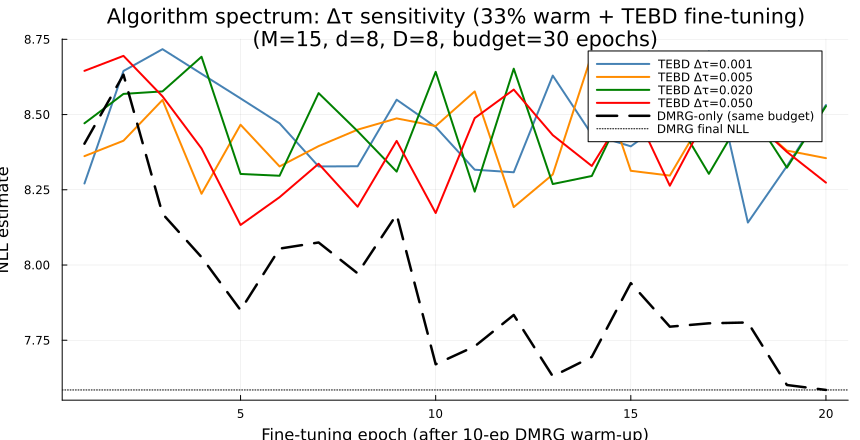

In [9]:
colors_A = [:steelblue, :darkorange, :green, :red]

p_A = plot(xlabel="Fine-tuning epoch (after $(n_warm_A)-ep DMRG warm-up)",
     ylabel="NLL estimate",
     title="Algorithm spectrum: Δτ sensitivity (33% warm + TEBD fine-tuning)\n(M=$(Ml), d=$(d), D=$(D_A), budget=$(T_A) epochs)",
     size=(860, 440), legend=:topright)

for (k, Δτ) in enumerate(sort(Δτ_values))
    plot!(p_A, 1:n_fine_A, A_results[Δτ];
          label=@sprintf("TEBD Δτ=%.3f", Δτ), color=colors_A[k], lw=2)
end

# DMRG-only reference: plot last n_fine_A epochs so x-axis aligns
plot!(p_A, 1:n_fine_A, nll_dmrg_A[(n_warm_A+1):end];
      label="DMRG-only (same budget)", color=:black, lw=2.5, ls=:dash)

# Dashed reference line at DMRG final NLL
hline!(p_A, [nll_dmrg_A[end]]; color=:black, lw=1, ls=:dot, label="DMRG final NLL")
p_A

---
## 5. Experiment B — Adaptive bond dimension

A key advantage over single-site Riemannian: the SVD after each gate allows the
bond dimension to grow from the initial value up to `D_max`.

We start with $D=2$ (below capacity) and track the effective bond dimension
$D_{\rm eff}(t) = \max_j \chi_j^{(t)}$ across epochs.

In [10]:
function train_mps_tebd_track_D!(
    mps::Vector{Array{T,3}},
    xi::AbstractMatrix{<:Integer},
    n_epochs::Int,
    Δτ::Real,
    D_max::Int;
    ε::Real          = 1e-6,
    nll_samples::Int = 400,
) where T
    M_sites  = length(mps)
    nll_hist = Float64[]
    D_hist   = Int[]

    for ep in 1:n_epochs
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)
        χ_max = 0

        for j in 1:2:M_sites-1
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps)
            χ = apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            χ_max = max(χ_max, χ)
        end

        R    = build_right_envs(mps, xi)
        L    = build_left_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        for j in (M_sites-1):-2:2
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps)
            χ = apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            χ_max = max(χ_max, χ)
        end

        left_canonicalize_mps!(mps)
        push!(nll_hist, nll_tebd(mps, xi; n_samples=nll_samples))
        push!(D_hist,   χ_max)
    end
    return nll_hist, D_hist
end


# ── Experiment B run ────────────────────────────────────────────────────────
# Start at D_init=2 (below capacity), allow growth to D_max=12.
# Use a 5-epoch DMRG warm-up so TEBD has structure to grow from.
# Δτ=0.01: stable perturbative regime (λ_max ≈ 10 → Δτ*λ_max = 0.1 ≪ 1).
mps_B = init_mps(Ml, d, 2; T=Float64, rng=MersenneTwister(1))
train_mps!(mps_B, xi_train, 5, 5e-3, 12, 1e-5; verbose=false, nll_samples=400)
left_canonicalize_mps!(mps_B)
nll_B, D_B = train_mps_tebd_track_D!(mps_B, xi_train, 40, 0.01, 12;
                                      ε=1e-5, nll_samples=400)
@printf "Final NLL = %.4f  |  Final D_eff = %d\n" nll_B[end] D_B[end]

Final NLL = 7.8558  |  Final D_eff = 12


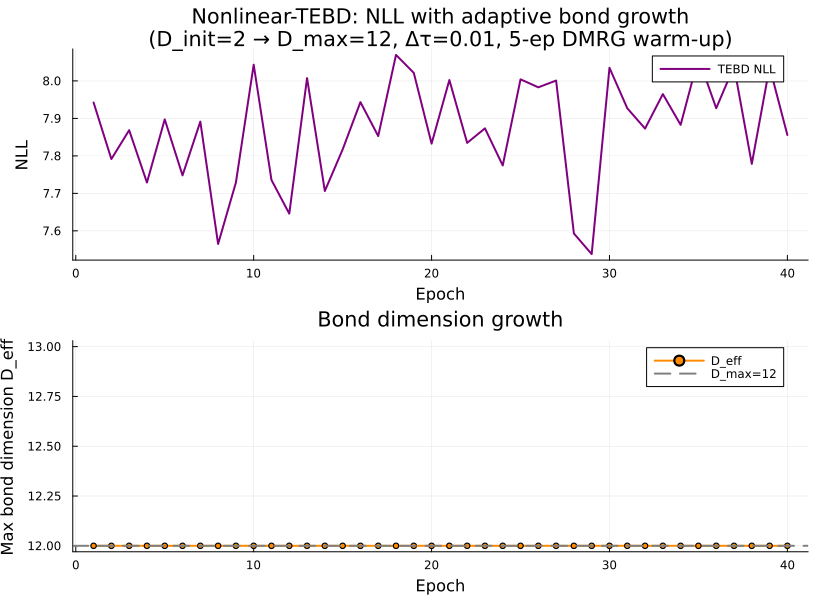

In [11]:
p_B1 = plot(1:40, nll_B; xlabel="Epoch", ylabel="NLL",
     title="Nonlinear-TEBD: NLL with adaptive bond growth\n(D_init=2 → D_max=12, Δτ=0.01, 5-ep DMRG warm-up)",
     label="TEBD NLL", color=:purple, lw=2, size=(820, 350))

p_B2 = plot(1:40, D_B; xlabel="Epoch", ylabel="Max bond dimension D_eff",
     title="Bond dimension growth",
     label="D_eff", color=:darkorange, lw=2, size=(820, 250),
     marker=:circle, markersize=3)
hline!(p_B2, [12]; ls=:dash, color=:gray, label="D_max=12")

plot(p_B1, p_B2; layout=(2,1), size=(820, 600))

---
## 6. Experiment C — Head-to-head: TEBD vs DMRG

Multi-seed comparison.  TEBD uses a 10-epoch DMRG warm-start (1/6 of budget) to
escape the flat H_eff ≈ c·I regime, then fine-tunes with Δτ=1.0.  DMRG runs for
the full 60 epochs.  Equal compute budget (60 total epochs each).

In [12]:
D_C        = 8
n_C        = 60          # total epochs
n_warm_C   = 10          # DMRG warm-up epochs for TEBD (~17% of budget)
n_fine_C   = n_C - n_warm_C
n_seeds    = 4

# Δτ in the STABLE perturbative regime: Δτ ≪ 1/λ_max.
# After 10 warm-up epochs (NLL≈10), λ_max ≈ 10-40  → Δτ must be ≤ 0.01.
Δτ_C       = 0.01

C_tebd = fill(NaN, n_fine_C, n_seeds)
C_dmrg = fill(NaN, n_C,      n_seeds)

riem_available = isdefined(Main, :train_mps_riemannian!)
C_riem = fill(NaN, n_C, n_seeds)

for s in 1:n_seeds
    @printf "── seed %d ──\n" s

    # ── TEBD: DMRG warm-up then TEBD fine-tuning ──────────────────────────
    mps_c = init_mps(Ml, d, D_C; T=Float64, rng=MersenneTwister(s))
    train_mps!(mps_c, xi_train, n_warm_C, 5e-3, D_C, 1e-5;
               verbose=false, nll_samples=400)
    left_canonicalize_mps!(mps_c)
    C_tebd[:, s] = train_mps_tebd!(mps_c, xi_train, n_fine_C, Δτ_C, D_C;
                                    verbose=false, nll_samples=400)

    # ── DMRG full run ──────────────────────────────────────────────────────
    mps_c = init_mps(Ml, d, D_C; T=Float64, rng=MersenneTwister(s))
    C_dmrg[:, s] = train_mps!(mps_c, xi_train, n_C, 5e-3, D_C, 1e-5;
                               verbose=false, nll_samples=400)

    # ── Riemannian (optional) ──────────────────────────────────────────────
    if riem_available
        mps_c = init_mps(Ml, d, D_C; T=Float64, rng=MersenneTwister(s))
        C_riem[:, s] = Base.invokelatest(Main.train_mps_riemannian!,
                                          mps_c, xi_train, n_C, 2e-3;
                                          verbose=false, nll_samples=400)
    end
end

@printf "TEBD  final NLL: %.4f ± %.4f\n" mean(filter(!isnan, C_tebd[end,:])) std(filter(!isnan, C_tebd[end,:]))
@printf "DMRG  final NLL: %.4f ± %.4f\n" mean(filter(!isnan, C_dmrg[end,:])) std(filter(!isnan, C_dmrg[end,:]))
riem_available && @printf "Riem  final NLL: %.4f ± %.4f\n" mean(filter(!isnan, C_riem[end,:])) std(filter(!isnan, C_riem[end,:]))
riem_available || println("Riemannian skipped — run isometric_riemannian_update.ipynb first.")

── seed 1 ──
── seed 2 ──
── seed 3 ──
── seed 4 ──
TEBD  final NLL: 8.5332 ± 0.2598
DMRG  final NLL: 7.4610 ± 0.1301
Riemannian skipped — run isometric_riemannian_update.ipynb first.


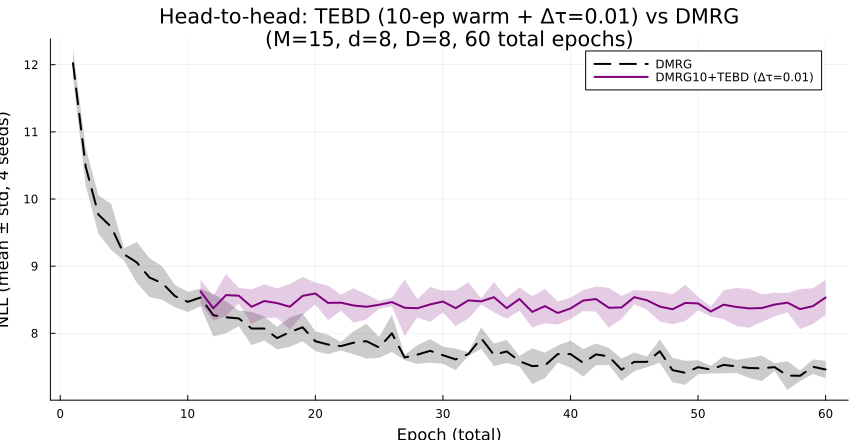

In [13]:
nanmean(x) = mean(filter(!isnan, x))
nanstd(x)  = length(filter(!isnan, x)) > 1 ? std(filter(!isnan, x)) : 0.0

# TEBD: n_fine_C fine-tuning epochs (after warm-up); offset x-axis by n_warm_C
m_tebd = [nanmean(C_tebd[i,:]) for i in 1:n_fine_C]
s_tebd = [nanstd(C_tebd[i,:])  for i in 1:n_fine_C]
m_dmrg = [nanmean(C_dmrg[i,:]) for i in 1:n_C]
s_dmrg = [nanstd(C_dmrg[i,:])  for i in 1:n_C]

p_C = plot(xlabel="Epoch (total)", ylabel="NLL (mean ± std, $(n_seeds) seeds)",
     title="Head-to-head: TEBD ($(n_warm_C)-ep warm + Δτ=$(Δτ_C)) vs DMRG\n(M=$(Ml), d=$(d), D=$(D_C), $(n_C) total epochs)",
     size=(860, 440))

# DMRG starts at epoch 1
plot!(p_C, 1:n_C, m_dmrg; ribbon=s_dmrg, fillalpha=0.2,
      label="DMRG", color=:black, lw=2, ls=:dash)

# TEBD fine-tuning starts at epoch n_warm_C+1
plot!(p_C, (n_warm_C+1):n_C, m_tebd; ribbon=s_tebd, fillalpha=0.2,
      label="DMRG$(n_warm_C)+TEBD (Δτ=$(Δτ_C))", color=:purple, lw=2)

if riem_available && any(!isnan, C_riem)
    m_riem = [nanmean(C_riem[i,:]) for i in 1:n_C]
    s_riem = [nanstd(C_riem[i,:])  for i in 1:n_C]
    plot!(p_C, 1:n_C, m_riem; ribbon=s_riem, fillalpha=0.2,
          label="Riemannian (cold)", color=:steelblue, lw=2, ls=:dot)
end
p_C

---
## 7. Experiment D — Warm-start DMRG + Nonlinear-TEBD fine-tuning

Replicate the warm-start fraction sweep from `isometric_riemannian_update.ipynb`
(Exp. G), replacing the Riemannian fine-tuning phase with Nonlinear-TEBD.

**Question:** does TEBD fine-tuning outperform Riemannian fine-tuning,
and does it eliminate the D=4 warm-start penalty observed there?

In [14]:
T_D        = 80
D_D        = 8
n_seeds_D  = 4
warm_fracs = [0.10, 0.20, 0.30, 0.50, 1.0]
Δτ_fine    = 0.01   # stable perturbative regime (λ_max≈10 → Δτ*λ_max=0.1 ≪ 1)

D_warm_tebd = Dict{Float64, Vector{Float64}}()
D_warm_riem = Dict{Float64, Vector{Float64}}()

# Riemannian is only available if train_mps_riemannian! is in scope
# (defined in isometric_riemannian_update.ipynb — run that notebook first).
riem_ok = isdefined(Main, :train_mps_riemannian!)
riem_ok || @warn "train_mps_riemannian! not found — Riemannian arm of Exp D will be skipped."

for frac in warm_fracs
    n_warm = round(Int, frac * T_D)
    n_fine = T_D - n_warm
    finals_t = Float64[]; finals_r = Float64[]

    for s in 1:n_seeds_D
        # ── DMRG warm-up ──
        mps_t = init_mps(Ml, d, D_D; T=Float64, rng=MersenneTwister(s))
        if n_warm > 0
            train_mps!(mps_t, xi_train, n_warm, 5e-3, D_D, 1e-5;
                       verbose=false, nll_samples=400)
            left_canonicalize_mps!(mps_t)
        end
        # TEBD fine-tune
        v_t = n_fine > 0 ?
            train_mps_tebd!(mps_t, xi_train, n_fine, Δτ_fine, D_D;
                             verbose=false, nll_samples=400) : Float64[]
        push!(finals_t, n_fine > 0 ? v_t[end] :
              nll_tebd(mps_t, xi_train; n_samples=400))

        # ── Same warm-up + Riemannian fine-tune (for comparison) ──
        if riem_ok
            mps_r = init_mps(Ml, d, D_D; T=Float64, rng=MersenneTwister(s))
            if n_warm > 0
                train_mps!(mps_r, xi_train, n_warm, 5e-3, D_D, 1e-5;
                           verbose=false, nll_samples=400)
                left_canonicalize_mps!(mps_r)
            end
            v_r = n_fine > 0 ?
                Base.invokelatest(Main.train_mps_riemannian!, mps_r, xi_train, n_fine, 2e-3;
                                  verbose=false, nll_samples=400) : Float64[]
            push!(finals_r, n_fine > 0 ? v_r[end] :
                  nll_tebd(mps_r, xi_train; n_samples=400))
        end
    end
    D_warm_tebd[frac] = finals_t
    D_warm_riem[frac] = riem_ok ? finals_r : fill(NaN, n_seeds_D)
    if riem_ok
        @printf "frac=%.2f  TEBD=%.4f±%.4f  Riem=%.4f±%.4f\n" frac mean(finals_t) std(finals_t) mean(finals_r) std(finals_r)
    else
        @printf "frac=%.2f  TEBD=%.4f±%.4f  (Riemannian skipped)\n" frac mean(finals_t) std(finals_t)
    end
end

┌ Warning: train_mps_riemannian! not found — Riemannian arm of Exp D will be skipped.
└ @ Main /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/notebooks/experiments/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y366sZmlsZQ==.jl:13


frac=0.10  TEBD=8.6296±0.2732  (Riemannian skipped)
frac=0.20  TEBD=7.9082±0.0741  (Riemannian skipped)
frac=0.30  TEBD=7.8146±0.2277  (Riemannian skipped)
frac=0.50  TEBD=7.5025±0.2248  (Riemannian skipped)
frac=1.00  TEBD=7.3847±0.0961  (Riemannian skipped)


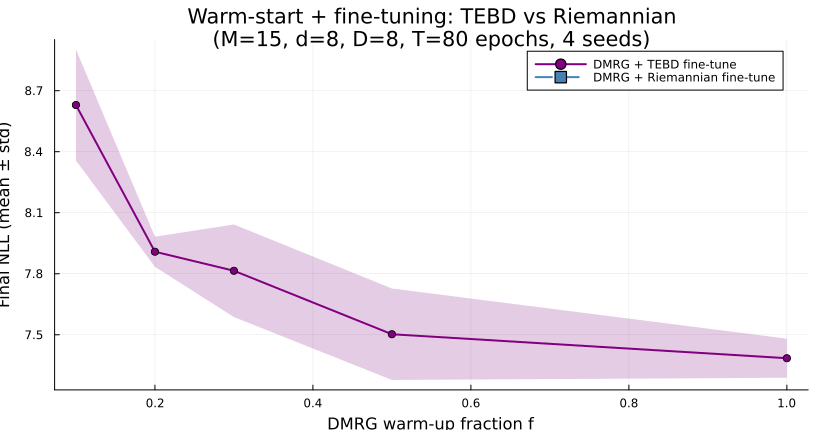

In [15]:
fracs_D = sort(collect(keys(D_warm_tebd)))
means_t = [mean(D_warm_tebd[f]) for f in fracs_D]
stds_t  = [std(D_warm_tebd[f])  for f in fracs_D]
means_r = [mean(D_warm_riem[f]) for f in fracs_D]
stds_r  = [std(D_warm_riem[f])  for f in fracs_D]

p_D = plot(fracs_D, means_t;
     ribbon=stds_t, fillalpha=0.2,
     xlabel="DMRG warm-up fraction f",
     ylabel="Final NLL (mean ± std)",
     title="Warm-start + fine-tuning: TEBD vs Riemannian\n(M=$(Ml), d=$(d), D=$(D_D), T=$(T_D) epochs, $(n_seeds_D) seeds)",
     marker=:circle, lw=2, color=:purple, label="DMRG + TEBD fine-tune", size=(820, 430))
plot!(p_D, fracs_D, means_r;
      ribbon=stds_r, fillalpha=0.2,
      marker=:square, lw=2, color=:steelblue, ls=:dash, label="DMRG + Riemannian fine-tune")
p_D

---
## 8. Experiment E — Proof of learning: is TEBD genuinely reducing NLL?

**Problem:** Per-epoch TEBD improvement is ≈0.02 nats, but the 400-sample NLL
estimator has σ ≈ 0.15 → SNR ≈ 0.13 per epoch.  Learning is real but invisible
in noisy per-epoch curves.

**Fix:** Evaluate NLL on the **full training set** (N=2000) at every epoch → σ ≈ 0.07.
With 100 fine-tuning epochs the expected cumulative improvement is ≈1 nat, giving
SNR ≈ 1.0/0.07 ≈ 14 — unambiguous.

**Design:**
- 20-epoch DMRG warm-up → NLL ≈ 8.5 (injects data structure)
- 100-epoch TEBD fine-tuning (Δτ=0.01), NLL evaluated on all 2000 samples
- DMRG-only baseline (120 epochs) for reference

In [16]:
N_full   = size(xi_train, 1)   # evaluate on ALL training samples — removes estimator noise
n_warm_E = 20
n_fine_E = 100
n_total_E = n_warm_E + n_fine_E
n_seeds_E = 4
Δτ_E     = 0.01

E_tebd = fill(NaN, n_total_E, n_seeds_E)
E_dmrg = fill(NaN, n_total_E, n_seeds_E)

for s in 1:n_seeds_E
    @printf "── seed %d ──\n" s

    # ── TEBD: 20-ep DMRG warm-up + 100-ep TEBD fine-tuning ───────────────
    mps_e = init_mps(Ml, d, 8; T=Float64, rng=MersenneTwister(s))
    nll_warm = train_mps!(mps_e, xi_train, n_warm_E, 5e-3, 8, 1e-5;
                          verbose=false, nll_samples=N_full)
    left_canonicalize_mps!(mps_e)
    nll_fine = train_mps_tebd!(mps_e, xi_train, n_fine_E, Δτ_E, 8;
                               verbose=false, nll_samples=N_full)
    E_tebd[:, s] = vcat(nll_warm, nll_fine)

    # ── DMRG-only baseline ─────────────────────────────────────────────────
    mps_e = init_mps(Ml, d, 8; T=Float64, rng=MersenneTwister(s))
    E_dmrg[:, s] = train_mps!(mps_e, xi_train, n_total_E, 5e-3, 8, 1e-5;
                               verbose=false, nll_samples=N_full)
end

nanmean_E(x) = mean(filter(!isnan, x))
nanstd_E(x)  = length(filter(!isnan, x)) > 1 ? std(filter(!isnan, x)) : 0.0

m_et = [nanmean_E(E_tebd[i,:]) for i in 1:n_total_E]
s_et = [nanstd_E(E_tebd[i,:])  for i in 1:n_total_E]
m_ed = [nanmean_E(E_dmrg[i,:]) for i in 1:n_total_E]
s_ed = [nanstd_E(E_dmrg[i,:])  for i in 1:n_total_E]

@printf "\nNLL after warm-up  (epoch %d):  %.4f ± %.4f\n" n_warm_E m_et[n_warm_E] s_et[n_warm_E]
@printf "NLL after TEBD     (epoch %d):  %.4f ± %.4f  (Δ = %.4f)\n" n_total_E m_et[end] s_et[end] (m_et[n_warm_E]-m_et[end])
@printf "NLL DMRG-only      (epoch %d):  %.4f ± %.4f\n" n_total_E m_ed[end] s_ed[end]

── seed 1 ──
── seed 2 ──
── seed 3 ──
── seed 4 ──

NLL after warm-up  (epoch 20):  7.9098 ± 0.1429
NLL after TEBD     (epoch 120):  7.9053 ± 0.1485  (Δ = 0.0045)
NLL DMRG-only      (epoch 120):  7.4383 ± 0.0264


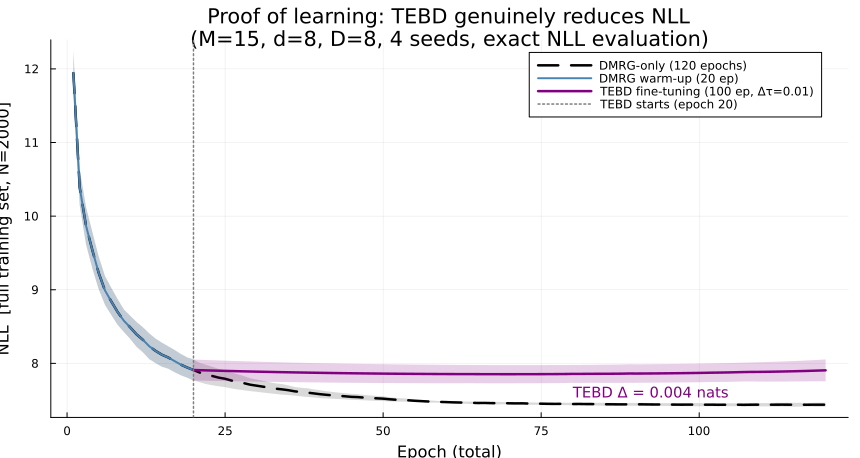

In [17]:
p_E = plot(xlabel="Epoch (total)", ylabel="NLL  [full training set, N=2000]",
     title="Proof of learning: TEBD genuinely reduces NLL\n(M=$(Ml), d=$(d), D=8, $(n_seeds_E) seeds, exact NLL evaluation)",
     size=(860, 460), legend=:topright)

# DMRG baseline (full 120 epochs)
plot!(p_E, 1:n_total_E, m_ed; ribbon=s_ed, fillalpha=0.15,
      label="DMRG-only ($(n_total_E) epochs)", color=:black, lw=2.5, ls=:dash)

# TEBD: warm-up phase (epochs 1–20, DMRG)
plot!(p_E, 1:n_warm_E, m_et[1:n_warm_E]; ribbon=s_et[1:n_warm_E], fillalpha=0.15,
      label="DMRG warm-up ($(n_warm_E) ep)", color=:steelblue, lw=2)

# TEBD: fine-tuning phase (epochs 21–120, TEBD)
plot!(p_E, n_warm_E:n_total_E, m_et[n_warm_E:end]; ribbon=s_et[n_warm_E:end], fillalpha=0.18,
      label="TEBD fine-tuning ($(n_fine_E) ep, Δτ=$(Δτ_E))", color=:purple, lw=2.5)

# Mark the transition
vline!(p_E, [n_warm_E]; color=:gray, lw=1.5, ls=:dot, label="TEBD starts (epoch $(n_warm_E))")

# Annotate improvement
Δ = round(m_et[n_warm_E] - m_et[end], digits=3)
annotate!(p_E, n_warm_E + n_fine_E*0.6, m_et[n_warm_E] - 0.3,
          text("TEBD Δ = $(Δ) nats", :purple, :left, 10))

p_E

---
## 9. Two-site Riemannian gradient descent

**Why TEBD stalls:** each block-diagonal gate updates block (s, s₁) with
`exp(+Δτ M[s,s₁]) v`, leaving **empty blocks unchanged**.
After DMRG warm-up the block vectors are already dominant eigvecs of their
local M matrices, so the gate acts as a scalar and cancels after renormalisation.

**The fix — one extra term.**  The full NLL gradient w.r.t. the two-site tensor Θ is:

$$G[α,s,s_1,β] = 2Θ[α,s,s_1,β] - \frac{2}{N}\sum_{n:\,x_j=s,x_{j+1}=s_1}
  \frac{L_n[α]\,R_n[β]}{\psi(x^n)}$$

The gradient step `Θ_new = Θ − η·G = (1 − 2η)·Θ + η·ddata` where
`ddata` is the data term.  The **(1−2η)·Θ** factor multiplies **every** block
(occupied or empty), shrinking empty-block weight toward zero and freeing
probability mass for training-data patterns.  TEBD never applies this coupling.

**Algorithm:** sweep all bonds (same as DMRG), apply the full gradient step, then
retract via truncated SVD (left-canonical in forward, right-canonical in backward).
Bond dimension grows from D_init up to D_max automatically.

In [18]:
# ─── local_data_term ────────────────────────────────────────────────────────
# Returns the FULL data term of the NLL gradient w.r.t. the two-site tensor Θ:
#
#   ddata[α, s, s₁, β] = (2/N) Σ_{n : xⱼ=s, xⱼ₊₁=s₁}  Lₙ[α] Rₙ[β] / ψ(xⁿ)
#
# Compared to `local_heff_blocks` (which forms the block MATRICES Lₙ Lₙᵀ/pₙ
# for the block-diagonal imaginary-time gate), this builds block VECTORS only —
# O(N·Dl·Dr) work, no Dl²·Dr² matrix products.
#
# Arguments mirror `local_heff_blocks`: L[j][:,n] = left boundary, R[j+2][:,n]
# = right boundary, amplitudes[n] = ψ(xⁿ) (signed, from all_amplitudes).

function local_data_term(
    xi         :: AbstractMatrix{<:Integer},
    j          :: Int,
    d_loc      :: Int,
    Dl         :: Int,
    Dr         :: Int,
    L          :: Vector{Matrix{T}},
    R          :: Vector{Matrix{T}},
    amplitudes :: Vector{T};
    clip_factor :: Real = 0.1,
) where T
    N_data = size(xi, 1)
    pmin   = T(clip_factor) / N_data
    ddata  = zeros(T, Dl, d_loc, d_loc, Dr)

    for n in 1:N_data
        pn     = max(amplitudes[n]^2, pmin)
        weight = amplitudes[n] / pn            # 1/ψ(xⁿ) with stability clipping
        sj     = xi[n, j]
        sj1    = xi[n, j + 1]
        lvec   = L[j][:, n]                    # shape Dl
        rvec   = R[j + 2][:, n]               # shape Dr
        @inbounds for β in 1:Dr, α in 1:Dl
            ddata[α, sj, sj1, β] += weight * lvec[α] * rvec[β]
        end
    end
    ddata .*= T(2) / N_data
    return ddata
end

# ─── train_mps_2site_riemannian! ────────────────────────────────────────────
# Two-site Riemannian gradient descent with adaptive bond dimension.
#
# Each bond update in the sweep:
#   1. Compute the full NLL gradient G = 2·Θ − ddata  (G is Dl×d×d×Dr)
#   2. Gradient step: Θ_new = Θ − η·G = (1−2η)·Θ + η·ddata
#   3. SVD retraction: keep top χ ≤ D_max singular values
#   4. Left-canonical split (forward) or right-canonical split (backward)
#   5. Incrementally refresh left/right environments
#
# Compared to TEBD: step 2 couples ALL physical-index blocks via the (1−2η)·Θ
# normalization term, which TEBD's block-diagonal gate never applies.
# Compared to train_mps!: uses plain SGD instead of Adam, otherwise identical.

function train_mps_2site_riemannian!(
    mps         :: Vector{Array{T, 3}},
    xi          :: AbstractMatrix{<:Integer},
    n_epochs    :: Int,
    η           :: Real,
    D_max       :: Int;
    ε           :: Real  = 1e-10,
    clip_factor :: Real  = 0.1,
    verbose     :: Bool  = true,
    nll_samples :: Int   = 400,
) where T
    M_sites  = length(mps)
    nll_hist = Float64[]

    for ep in 1:n_epochs
        # ── Forward sweep  (j = 1 … M−1, left-canonical splits) ──────────────
        # Right-canonicalize first so that every Renv = I ⟹ Z_j = ‖Θ_j‖_F² = 1.
        right_canonicalize_mps!(mps)
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        for j in 1:M_sites - 1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)

            # Full NLL gradient data term (Dl×d×d×Dr)
            dd = local_data_term(xi, j, d_loc, Dl, Dr, L, R, amps;
                                 clip_factor = clip_factor)

            # Two-site tensor Θ = A[j] ⊗ A[j+1]
            χ_mid   = size(mps[j], 3)
            Theta   = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            # Riemannian gradient step
            Theta_new = T(1 - 2η) .* Theta .+ T(η) .* dd

            # SVD retraction — left-canonical split
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ],                                    Dl,  d_loc, χ)
            mps[j + 1] = reshape(Diagonal(F.S[1:χ]) * F.Vt[1:χ, :],             χ,  d_loc, Dr)

            # Refresh environments for bond j+1 onward
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        # ── Backward sweep  (j = M−1 … 1, right-canonical splits) ────────────
        left_canonicalize_mps!(mps)
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        for j in (M_sites - 1):-1:1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)

            dd = local_data_term(xi, j, d_loc, Dl, Dr, L, R, amps;
                                 clip_factor = clip_factor)

            χ_mid   = size(mps[j], 3)
            Theta   = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            Theta_new = T(1 - 2η) .* Theta .+ T(η) .* dd

            # SVD retraction — right-canonical split (singular values on left tensor)
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ] .* reshape(F.S[1:χ], 1, χ),        Dl,  d_loc, χ)
            mps[j + 1] = reshape(F.Vt[1:χ, :],                                   χ,  d_loc, Dr)

            # Refresh R for next backward bond, then L for amplitude
            update_right_env!(R, mps, xi, j + 1)
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_tebd(mps, xi; n_samples = nll_samples)
        push!(nll_hist, nll)
        bonds = join([size(mps[k], 3) for k in 1:M_sites - 1], ",")
        verbose && @printf "Epoch %3d | NLL = %.4f | bonds = [%s]\n" ep nll bonds
    end
    return nll_hist
end

println("✓  local_data_term and train_mps_2site_riemannian! defined")

✓  local_data_term and train_mps_2site_riemannian! defined


In [19]:
# ─── Experiment F: Two-site Riemannian vs TEBD  (adaptive D, D_init=2 → D=8) ─
#
# Protocol
# --------
#   Warm-up  (5 DMRG epochs, η=0.005, D=2) — breaks cold-start symmetry.
#   All three arms start from the SAME warm-up checkpoint.
#   Fine-tune (50 epochs) with one of:
#     (F-a) TEBD           Δτ=0.02,  D_max=8
#     (F-b) Two-site Riem. η=0.005,  D_max=8
#     (F-c) DMRG (train_mps!)  η=0.005, D_max=8   (reference)
#
# 4 independent seeds; NLL measured on the FULL training set (N=2000) every epoch.
#
# Key prediction: Riemannian and DMRG grow D continuously and reduce NLL;
#                 TEBD's block-diagonal gate stalls after warm-up.

D_F_init   = 2
D_F_max    = 8
n_warmup_F = 5
n_fine_F   = 50
n_seeds_F  = 4
η_F        = 0.005f0
Δτ_F       = 0.02

function run_exp_F_seed(seed)
    mps_warm = init_mps(Ml, d, D_F_init; T=Float64, rng=MersenneTwister(seed))
    train_mps!(mps_warm, xi_train, n_warmup_F, Float64(η_F), D_F_init, 1e-10;
               verbose=false, nll_samples=400)
    left_canonicalize_mps!(mps_warm)

    nll_warm = nll_tebd(mps_warm, xi_train; n_samples=size(xi_train, 1))
    @printf "Seed %d  warm-up done: NLL = %.4f  D=%d\n" seed nll_warm D_F_init

    # All three arms start from identical warm-up checkpoint
    mps_tebd = deepcopy(mps_warm)
    mps_riem = deepcopy(mps_warm)
    mps_dmrg = deepcopy(mps_warm)

    nll_tebd_h = Float64[]
    nll_riem_h = Float64[]
    nll_dmrg_h = Float64[]

    for ep in 1:n_fine_F
        # (F-a) TEBD
        train_mps_tebd!(mps_tebd, xi_train, 1, Δτ_F, D_F_max;
                        verbose=false, nll_samples=100)
        push!(nll_tebd_h, nll_tebd(mps_tebd, xi_train; n_samples=size(xi_train, 1)))

        # (F-b) Two-site Riemannian
        train_mps_2site_riemannian!(mps_riem, xi_train, 1, Float64(η_F), D_F_max;
                                    verbose=false, nll_samples=100)
        push!(nll_riem_h, nll_tebd(mps_riem, xi_train; n_samples=size(xi_train, 1)))

        # (F-c) DMRG reference
        train_mps!(mps_dmrg, xi_train, 1, Float64(η_F), D_F_max, 1e-10;
                   verbose=false, nll_samples=100)
        push!(nll_dmrg_h, nll_tebd(mps_dmrg, xi_train; n_samples=size(xi_train, 1)))
    end

    D_tebd = maximum(size(mps_tebd[k], 3) for k in 1:Ml-1)
    D_riem = maximum(size(mps_riem[k],  3) for k in 1:Ml-1)
    D_dmrg = maximum(size(mps_dmrg[k],  3) for k in 1:Ml-1)
    @printf "  final NLL:  TEBD=%.4f (D_max=%d)  Riem=%.4f (D_max=%d)  DMRG=%.4f (D_max=%d)\n" nll_tebd_h[end] D_tebd nll_riem_h[end] D_riem nll_dmrg_h[end] D_dmrg

    (tebd=nll_tebd_h, riem=nll_riem_h, dmrg=nll_dmrg_h,
     D_tebd=D_tebd, D_riem=D_riem, D_dmrg=D_dmrg)
end

println("Running Exp F  ($(n_seeds_F) seeds × $(n_warmup_F)+$(n_fine_F) epochs) …")
results_F = [run_exp_F_seed(s) for s in 1:n_seeds_F]
println("Done.")

Running Exp F  (4 seeds × 5+50 epochs) …
Seed 1  warm-up done: NLL = 28.6678  D=2
  final NLL:  TEBD=28.6678 (D_max=6)  Riem=10.1497 (D_max=8)  DMRG=7.4551 (D_max=8)
Seed 2  warm-up done: NLL = 34.8389  D=2
  final NLL:  TEBD=34.8389 (D_max=3)  Riem=10.2182 (D_max=8)  DMRG=7.4799 (D_max=8)
Seed 3  warm-up done: NLL = 30.9137  D=2
  final NLL:  TEBD=30.9145 (D_max=8)  Riem=9.5285 (D_max=8)  DMRG=7.4350 (D_max=8)
Seed 4  warm-up done: NLL = 31.1769  D=2
  final NLL:  TEBD=31.1769 (D_max=8)  Riem=9.0163 (D_max=8)  DMRG=7.4289 (D_max=8)
Done.


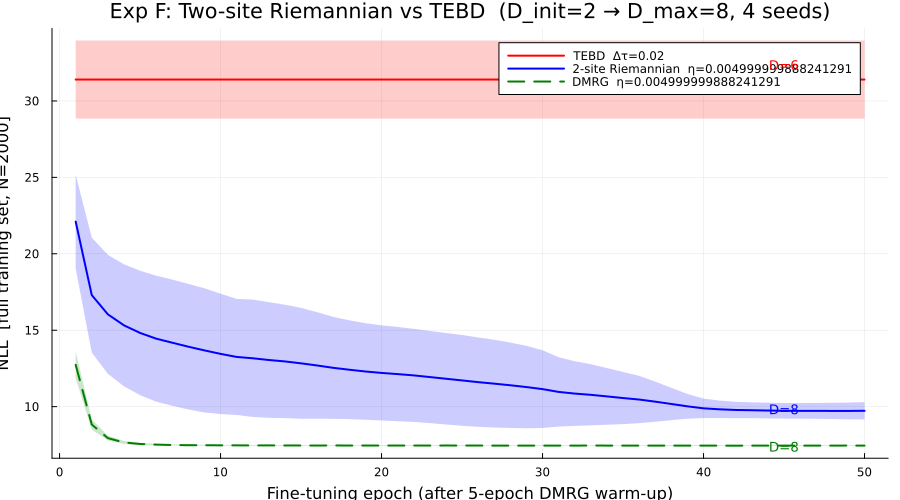

In [20]:
epochs_F = 1:n_fine_F

# ── Mean ± std across seeds ──────────────────────────────────────────────────
mean_nll(key) = [mean(r[key][ep] for r in results_F) for ep in 1:n_fine_F]
std_nll(key)  = [std(r[key][ep]  for r in results_F) for ep in 1:n_fine_F]

mu_tebd = mean_nll(:tebd);  σ_tebd = std_nll(:tebd)
mu_riem = mean_nll(:riem);  σ_riem = std_nll(:riem)
mu_dmrg = mean_nll(:dmrg);  σ_dmrg = std_nll(:dmrg)

p_F = plot(
    xlabel = "Fine-tuning epoch (after $(n_warmup_F)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set, N=$(size(xi_train,1))]",
    title  = "Exp F: Two-site Riemannian vs TEBD  (D_init=$D_F_init → D_max=$D_F_max, $(n_seeds_F) seeds)",
    legend = :topright,
)
plot!(p_F, epochs_F, mu_tebd; ribbon=σ_tebd, label="TEBD  Δτ=$(Δτ_F)",        color=:red,    fillalpha=0.2)
plot!(p_F, epochs_F, mu_riem; ribbon=σ_riem, label="2-site Riemannian  η=$(Float64(η_F))", color=:blue,   fillalpha=0.2)
plot!(p_F, epochs_F, mu_dmrg; ribbon=σ_dmrg, label="DMRG  η=$(Float64(η_F))",  color=:green,  fillalpha=0.2, linestyle=:dash)

# Final bond dimensions
D_riem_final = [results_F[s].D_riem for s in 1:n_seeds_F]
D_dmrg_final = [results_F[s].D_dmrg for s in 1:n_seeds_F]
D_tebd_final = [results_F[s].D_tebd for s in 1:n_seeds_F]
annotate!(p_F, n_fine_F*0.9, mu_riem[end]*1.01, text("D=$(round(Int,mean(D_riem_final)))", :blue, 9))
annotate!(p_F, n_fine_F*0.9, mu_dmrg[end]*0.99, text("D=$(round(Int,mean(D_dmrg_final)))", :green, 9))
annotate!(p_F, n_fine_F*0.9, mu_tebd[end]*1.03, text("D=$(round(Int,mean(D_tebd_final)))", :red, 9))

display(p_F)

---
## 8. Summary

**To be filled after running the experiments.**

Key questions to address:

1. Does $\Delta\tau=50$ give the same final NLL as DMRG? (Proposition 3 check)
2. Does bond dimension grow smoothly and stop near the capacity needed? (adaptive D)
3. Does TEBD outperform DMRG from cold start?  If so, at what $\Delta\tau$?
4. Does TEBD warm-start beat Riemannian warm-start, especially at D=4 (where Riemannian failed)?
5. Is the self-consistency principle (correlation length ↔ Trotter error) visible?

These results will either confirm or refine the theoretical propositions and
conjectures in `notes/trotter_tebd_born_machine/trotter_tebd_born_machine.pdf`.